## Clustering TEI documents based on XML tag branches

In this notebook we regard TEI-XML paths (e.g. `TEI.text.group.text.body.div.sp.l` rather than just `l`) as features, as carriers of the concepts the editor(s) wanted to annotated. The assumption is that TEI document let themselves be clustered according to the commensurate use of such path (documents that distinctly use the same XML paths will cluster together). The interpretation is that this tells us something about the different perspective from which the source have been edited. 

First we need to parse some TEI-XML documents into separate documents containing just all the XML-paths used in each document. 

In [103]:
from xml.parsers import expat

def branch_text_positions(xml_string):
    
    parser = expat.ParserCreate()

    results = []
    stack = []

    text_pos = 0  # position in tag-stripped text

    def to_branch( name ):
        tag_names = [ item['tag'] for item in stack ]
        tag_names.append( name )
        return '.'.join( tag_names )

    def start(name, attrs):
        nonlocal text_pos
        stack.append({
            "tag": name,
            "start": text_pos
        })

    def end(name):
        nonlocal text_pos
        item = stack.pop()
        item['tag'] = to_branch( item['tag'] )
        item['end'] = text_pos
        results.append(item)

    def char_data(data):
        nonlocal text_pos
        text_pos += len(data)

    parser.StartElementHandler = start
    parser.EndElementHandler = end
    parser.CharacterDataHandler = char_data

    parser.Parse(xml_string)

    return results

In [104]:
from glob import glob
import pandas

bp_dfs = {}

file_paths = glob( './data/**/*.xml' )
for file_path in file_paths:
    with open( file_path ) as xml_file:
        bp = branch_text_positions( xml_file.read() )
        bp_df = pandas.DataFrame( bp )
        bp_dfs[ file_path ] = bp_df

# Quick check…
bp_dfs[ list( bp_dfs.keys() )[1] ]

,tag,start,end
0,TEI.teiHeader.fileDesc.titleStmt.title,24,172
1,TEI.teiHeader.fileDesc.titleStmt.title,181,332
2,TEI.teiHeader.fileDesc.titleStmt.editor.persNa...,365,369
3,TEI.teiHeader.fileDesc.titleStmt.editor.persNa...,382,388
4,TEI.teiHeader.fileDesc.titleStmt.editor.persName,352,399
...,...,...,...
19247,TEI.sourceDoc.surface.zone.anchor,560216,560216
19248,TEI.sourceDoc.surface.zone,559828,560223
19249,TEI.sourceDoc.surface,559821,560228
19250,TEI.sourceDoc,9077,560231


 We need a TF&middot;IDF vectorizer for each individual document to weight each type of branch in each individual document. Branches (or paths) of TEI-XML tag look like `TEI.text.group.text.body.div.div.div.sp.lg.l.add` and `TEI.text.group.text.body.div.div.sp.speaker.abbr`. The latter tags provide significant distinctive information, but virtually all branches share the same first tags. Those tag basically provide no distinctive information at all. We TF&middot;IDF to represent what part of branches provide more distinctive information than others.

In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas

def create_branches_vectorizer():
    return TfidfVectorizer(
        token_pattern = None,
        tokenizer = lambda s: s.split( '.' ),  # split on period
        lowercase = False                      # keep as-is
    )


In [106]:
weights_docs = {}

for path_name, bp_df in bp_dfs.items():
    vectorizer = create_branches_vectorizer()
    weights_doc = vectorizer.fit_transform( bp_df[ 'tag' ] )
    df_tfidf = pandas.DataFrame( weights_doc.toarray(), columns=vectorizer.get_feature_names_out() )
    df_combined = pandas.concat( [bp_df, df_tfidf.mean( axis=1 )], axis=1 )
    df_combined.rename( columns={0:'weight'}, inplace=True )
    sorted_by_weight = ( 
        df_combined.groupby( 'tag', as_index=False )
            .agg( mean_weight=( 'weight', 'mean' ),  # .agg( new_column_name = ( 'existing_column_name', 'function_to_apply' )
                count=( 'weight', 'count' ) )
            .sort_values( by='mean_weight', ascending=False )
            .reset_index( drop=True )
        )
    weights_docs[ path_name ] = sorted_by_weight


In [113]:
weights_docs

{'./data/Kaiserchronik/ube_ce_8_24.tei.xml':                                                   tag  mean_weight  count
 0   TEI.teiHeader.fileDesc.sourceDesc.msDesc.addit...     0.043835      2
 1   TEI.teiHeader.fileDesc.sourceDesc.msDesc.addit...     0.043810      2
 2   TEI.teiHeader.fileDesc.sourceDesc.msDesc.addit...     0.043783      1
 3   TEI.teiHeader.fileDesc.publicationStmt.publish...     0.041021      1
 4   TEI.teiHeader.fileDesc.sourceDesc.msDesc.addit...     0.040957      1
 ..                                                ...          ...    ...
 92                         TEI.teiHeader.encodingDesc     0.024941      1
 93                         TEI.teiHeader.revisionDesc     0.022130      1
 94                                      TEI.sourceDoc     0.021980      1
 95                                      TEI.teiHeader     0.020216      1
 96                                                TEI     0.015625      1
 
 [97 rows x 3 columns],
 './data/Kaiserchronik/onb_cod

Now we have a dictionary with for each key (which is the pathname of an XML file) the weights for each branch found in that document.

Next we create a TF-IDF representing the branches in each XML document.

In [108]:
doc_vectorizer = TfidfVectorizer(
    token_pattern = None,
    tokenizer = lambda s: s.split( ' ' ),  # split on space
    lowercase = False                      # keep as-is
)

branch_docs = []

for key in weights_docs.keys():
    bp_df = bp_dfs[key]
    print( f'{len( bp_df['tag'].unique() )} unique branches in {key}' )
    branch_doc = ' '.join( bp_df['tag'].values )
    branch_docs.append( branch_doc )

tfidf_docs = doc_vectorizer.fit_transform( branch_docs )

97 unique branches in ./data/Kaiserchronik/ube_ce_8_24.tei.xml
118 unique branches in ./data/Kaiserchronik/onb_cod_2693.tei.xml
94 unique branches in ./data/Kaiserchronik/sbbw_frag6.tei.xml
115 unique branches in ./data/Kaiserchronik/onb_cod_13006.tei.xml
93 unique branches in ./data/Kaiserchronik/lkas_pat263.tei.xml
126 unique branches in ./data/Kaiserchronik/bsb_cgm37.tei.xml
97 unique branches in ./data/Kaiserchronik/bsb_cgm5249_70b.tei.xml
98 unique branches in ./data/Kaiserchronik/ulbt_fragm64.tei.xml
101 unique branches in ./data/Kaiserchronik/stbns_cod23_d_21_foll153-160.tei.xml
100 unique branches in ./data/Kaiserchronik/nsub_codms_wmueller_1_1.tei.xml
106 unique branches in ./data/Kaiserchronik/subhh_codtheol1546_beilage.tei.xml
103 unique branches in ./data/Kaiserchronik/cpg154.tei.xml
117 unique branches in ./data/Kaiserchronik/stav_ms276.tei.xml
96 unique branches in ./data/Kaiserchronik/onb_cod_12866.tei.xml
95 unique branches in ./data/Kaiserchronik/onb_codsn_215.tei.xml


In [109]:
tfidf_docs.shape

(60, 488)

Now the intricate part of combining TF-IDF and weights.

In [110]:
from scipy.sparse import lil_matrix

# Create a matrix the same size of the TF-IDF that contains all documents.
W = lil_matrix( tfidf_docs.shape )

for i, weights_doc in enumerate( weights_docs.values() ):

    # Get the weights
    branch_weights = list( zip( weights_doc['tag'], weights_doc['mean_weight'] ) )

    # Fill W with weights for each document
    for branch_weight in branch_weights:
        if branch_weight[0] in doc_vectorizer.vocabulary_:
            # find the column index of the feature ('tag') in the documents TF-IDF
            j = doc_vectorizer.vocabulary_[branch_weight[0]]
            # ut the weight on the same index in the weights matrix
            W[i, j] = branch_weight[1]


tfidf_docs_weighted = tfidf_docs.multiply( W )
print( tfidf_docs.toarray() )
print( tfidf_docs_weighted.toarray() )

[[1.80012603e-03 2.01954306e-03 8.07817224e-03 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [5.81056637e-05 6.51881524e-05 1.09516096e-02 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.25206950e-02 1.40468402e-02 2.80936803e-02 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [2.06319363e-03 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.24392150e-05 0.00000000e+00 0.00000000e+00 ... 3.02241787e-03
  0.00000000e+00 0.00000000e+00]
 [2.92711742e-04 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.29312047e-03 1.29312047e-03]]
[[2.81269692e-05 4.43894744e-05 2.17654417e-04 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [8.67248711e-07 1.37593904e-06 2.83109984e-04 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.98741190e-04 2.87307711e-04 7.24049223e-04 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [4.38977368e-05 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]

In [ ]:
from sklearn.cluster import KMeans

file_paths_clusterlabels = {}
kmeans = KMeans( n_clusters=3, random_state=0 )
labels = kmeans.fit_predict( tfidf_docs_weighted )

for i, label in enumerate( labels ):
    file_paths_clusterlabels[ file_paths[i] ] = label

df_clusters = pandas.DataFrame.from_dict( file_paths_clusterlabels, orient='index', columns=['cluster'] )
df_clusters.reset_index().rename(columns={ 'index': 'file_path' }).sort_values( by=['cluster','file_path'] )

,file_path,cluster
19,./data/Kaiserchronik/blb_augpap52.tei.xml,0
46,./data/Kaiserchronik/bnus_ms2215.tei.xml,0
33,./data/Kaiserchronik/bsb_cgm197.tei.xml,0
5,./data/Kaiserchronik/bsb_cgm37.tei.xml,0
25,./data/Kaiserchronik/bsb_cgm5249_70a.tei.xml,0
36,./data/Kaiserchronik/bsb_clm9503.tei.xml,0
11,./data/Kaiserchronik/cpg154.tei.xml,0
50,./data/Kaiserchronik/cpg361.tei.xml,0
29,./data/Kaiserchronik/hab_mss15-2-aug-2f.tei.xml,0
22,./data/Kaiserchronik/hak_best7010_(w)_353.tei.xml,0


In [130]:
from sklearn.cluster import DBSCAN

db = DBSCAN( eps=0.5, min_samples=1 )
labels = db.fit_predict( tfidf_docs_weighted )

for i, label in enumerate( labels ):
    file_paths_clusterlabels[ file_paths[i] ] = label

df_clusters = pandas.DataFrame.from_dict( file_paths_clusterlabels, orient='index', columns=['cluster'] )
df_clusters.reset_index().rename(columns={ 'index': 'file_path' }).sort_values( by=['cluster','file_path'] )

,file_path,cluster
59,./data/Chronik-Ulrich-Richental/UlrichRichenta...,0
58,./data/Der arme Heinrich/DAH_Edition_TEI.xml,0
19,./data/Kaiserchronik/blb_augpap52.tei.xml,0
46,./data/Kaiserchronik/bnus_ms2215.tei.xml,0
33,./data/Kaiserchronik/bsb_cgm197.tei.xml,0
5,./data/Kaiserchronik/bsb_cgm37.tei.xml,0
20,./data/Kaiserchronik/bsb_cgm5153b.tei.xml,0
25,./data/Kaiserchronik/bsb_cgm5249_70a.tei.xml,0
6,./data/Kaiserchronik/bsb_cgm5249_70b.tei.xml,0
36,./data/Kaiserchronik/bsb_clm9503.tei.xml,0


In [169]:
from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(n_clusters=3)
labels = clustering.fit_predict( tfidf_docs_weighted.toarray() )

for i, label in enumerate( labels ):
    file_paths_clusterlabels[ file_paths[i] ] = label

df_clusters = pandas.DataFrame.from_dict( file_paths_clusterlabels, orient='index', columns=['cluster'] )
df_clusters.reset_index().rename(columns={ 'index': 'file_path' }).sort_values( by=['cluster','file_path'] )

,file_path,cluster
59,./data/Chronik-Ulrich-Richental/UlrichRichenta...,0
58,./data/Der arme Heinrich/DAH_Edition_TEI.xml,0
20,./data/Kaiserchronik/bsb_cgm5153b.tei.xml,0
6,./data/Kaiserchronik/bsb_cgm5249_70b.tei.xml,0
42,./data/Kaiserchronik/fbk_bruchst1.tei.xml,0
17,./data/Kaiserchronik/h_baring.tei.xml,0
18,./data/Kaiserchronik/kbs_os.tei.xml,0
48,./data/Kaiserchronik/klak_cod_gv_6_26.tei.xml,0
4,./data/Kaiserchronik/lkas_pat263.tei.xml,0
3,./data/Kaiserchronik/onb_cod_13006.tei.xml,0


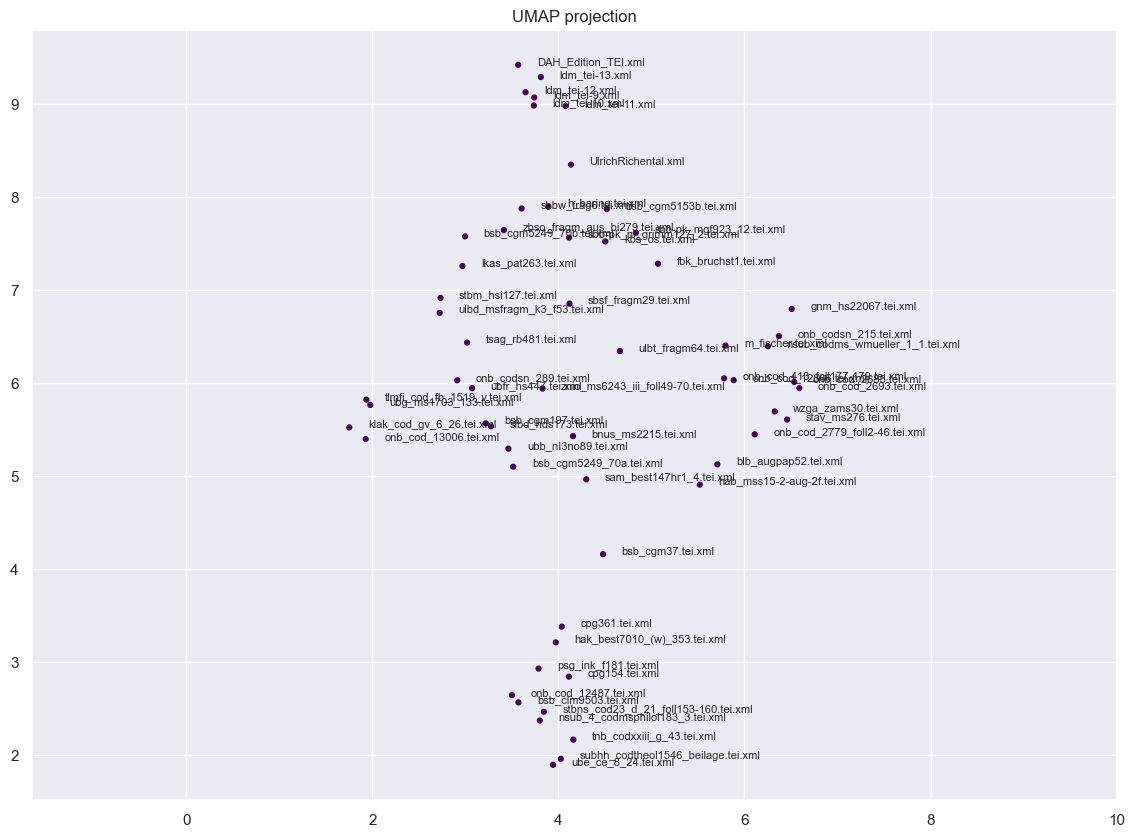

In [164]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

reducer = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric='cosine', 
    random_state=42
)
embedding = reducer.fit_transform( tfidf_docs_weighted )

plt.figure( figsize=(14, 10) )
plt.scatter( embedding[:, 0], embedding[:, 1], c=labels, cmap='viridis', s=12 )
plt.gca().set_aspect( 'equal', 'datalim' )
plt.title( 'UMAP projection' )
offset = 0.2
for i in range( 0, len( embedding ) ):
    plt.text( embedding[i,0] + offset, embedding[i,1], f'{file_paths[i].split('/')[-1]}', size=8 )
    
plt.show()

